---
#### 5-3. 비지도 학습 : Clustering
- K means, DB scan
---

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings("ignore")
# 시계열 데이터용 패키지 
import datetime
import datetime as dt 

In [2]:
# data loading 
df = pd.read_csv('data/online_retail.csv')
print(df.shape)
df.head()

(525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# 변수파악 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  object 
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.1+ MB


In [4]:
# 변수파악 
print('고객수 :', df['Customer ID'].nunique())
print('상품수 :', df['StockCode'].nunique())
print('주문수 :', df['Invoice'].nunique())
print('국가수 :', df['Country'].nunique())
print('주문 Top10 국가 :', df['Country'].value_counts()[:10])


고객수 : 4383
상품수 : 4632
주문수 : 28816
국가수 : 40
주문 Top10 국가 : Country
United Kingdom     485852
EIRE                 9670
Germany              8129
France               5772
Netherlands          2769
Spain                1278
Switzerland          1187
Portugal             1101
Belgium              1054
Channel Islands       906
Name: count, dtype: int64


In [5]:
# 결측치
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [6]:
# 분포 확인 
df.describe().iloc[:, :2]

,Quantity,Price
count,525461.000000,525461.000000
mean,10.337667,4.688834
std,107.424110,146.126914
min,-9600.000000,-53594.360000
25%,1.000000,1.250000
50%,3.000000,2.100000
75%,10.000000,4.210000
max,19152.000000,25111.090000


In [7]:
# 중복 데이터 확인 
print('중복 데이터 =', df.duplicated().sum())

dup_rows = df[df.duplicated(keep=False)].sort_values(by=['Invoice', 'StockCode']) 
dup_rows.head(10)

중복 데이터 = 6865


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom


- InvoiceDate의 타입이 object -> datetime 변환 필요 
- Customer ID에 결측치 존재 -> 비회원 구매, RFM 분석 의미 없음 
- Quantity, Price에 음수값 존재 -> 구매 취소 및 반품 등 비정상 거래 
- 데이터 중복 존재 -> 전산 오류 추정 

In [8]:
# InvoiceDate -> datetime 
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 비회원, 판매량/가격 음수, 중복 제거 
cond1 = df['Customer ID'].isnull()
cond2 = df['Quantity'] > 0 
cond3 = df['Price'] > 0 

df = df[
    (~cond1) & (cond2) & (cond3)
].drop_duplicates()

In [9]:
####################################################################
# Recency   : 고객별 마지막 주문일로 부터 기준일자(2010-12-10일) 까지의 경과일자  
# Frequency : 주문건수 
# Monetary  : 판매량 x 가격 
####################################################################

# 계산용 컬럼 
snapshot_date = pd.to_datetime('2010-12-10')
df['amount'] = df['Quantity'] * df['Price']

# RFM 계산 
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, 
    'Invoice': 'nunique',
    'amount': 'sum'
})

rfm = rfm.rename(columns = {
    'InvoiceDate' : 'Recency', 
    'Invoice' : 'Frequency', 
    'amount' : 'Monetary'
})

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,164,11,372.86
12347.0,2,2,1323.32
12348.0,73,1,222.16
12349.0,42,3,2671.14
12351.0,10,1,300.93


In [ ]:
####################################################################
# RFM score 부여 (1~5점)
# R은 수치가 낮을수록, F&M은 높을수록 좋은 점수
# qcut() 사용시 구분경계에 중복값이 있으면 에러 발생 -> rank(method='first') 사용
####################################################################

rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5,4,3,2,1]).astype(int)  
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)   
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)   

rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
Customer ID,,,,,,,
12346.0,164,11,372.86,2,5,2,9
12347.0,2,2,1323.32,5,2,4,11
12348.0,73,1,222.16,2,1,1,4
12349.0,42,3,2671.14,3,3,5,11
12351.0,10,1,300.93,5,1,2,8


<Axes: xlabel='RFM_score', ylabel='Count'>

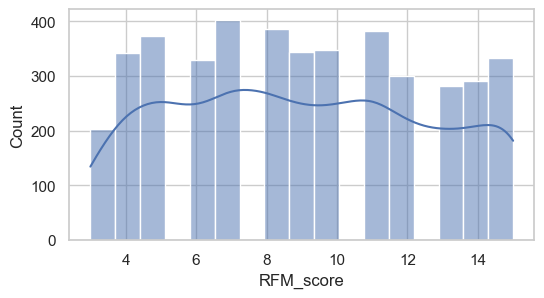

In [23]:
plt.figure(figsize=(6,3))
sns.histplot(data=rfm, x='RFM_score', kde=True)

---
#### 시나리오 1 
- 마케팅팀에서는 RFM 점수에 따라 고객을 아래 4개 등급으로 구분하기로 결정하였다. 
- 등급 구분을 위한 RFM 점수는 팀 간부들의 의견을 조율하여 다음과 같이 하기로 하였다. 
- VIP: 12점 초과 / Gold: 9~12점  / Silver: 5~9 / White: 기타 

In [26]:
def l_level(score): 
    if score > 12: 
        return 'VIP'
    elif score > 9:
        return 'Gold'
    elif score > 5: 
        return 'Silver'
    else: 
        return 'White'

rfm['Level'] = rfm['RFM_score'].apply(l_level)

display(rfm.head())
print(rfm['Level'].value_counts(normalize=True))

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Level
Customer ID,,,,,,,,
12346.0,164,11,372.86,2,5,2,9,Silver
12347.0,2,2,1323.32,5,2,4,11,Gold
12348.0,73,1,222.16,2,1,1,4,White
12349.0,42,3,2671.14,3,3,5,11,Gold
12351.0,10,1,300.93,5,1,2,8,Silver


Level
Silver    0.338590
Gold      0.238636
White     0.212662
VIP       0.210111
Name: proportion, dtype: float64


---
#### 시나리오 2 
- 고객등급 분류가 현실에 잘 맞지 않는다는 의견 제기됨 
- 분석팀에서는 기존의 경험적 구분이 아닌, 데이터 기반의 고객분류 기준을 찾기로 하였다. 

In [30]:
rfm.describe()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,90.172542,4.455705,2040.406712,3.000000,3.000000,3.000000,9.000000
std,96.861457,8.170213,8911.755977,1.414706,1.414706,1.414706,3.575283
min,0.000000,1.000000,2.950000,1.000000,1.000000,1.000000,3.000000
25%,17.000000,1.000000,307.187500,2.000000,2.000000,2.000000,6.000000
50%,52.000000,2.000000,701.615000,3.000000,3.000000,3.000000,9.000000
75%,135.000000,5.000000,1714.932500,4.000000,4.000000,4.000000,12.000000
max,373.000000,205.000000,349164.350000,5.000000,5.000000,5.000000,15.000000


[12936.000000000004, 9338.479548579977, 5160.253150194539, 3587.3130402909155, 3117.746633374861, 2355.3703176502645, 1820.8586719339964, 1604.2872935837495, 1415.5667178459103, 1264.1741118547297]


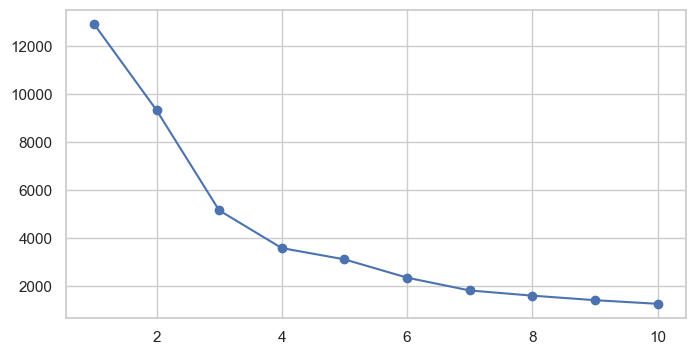

In [42]:
# 변수 표준화 
rfm2 = rfm[['Recency', 'Frequency', 'Monetary']]

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm2 = scaler.fit_transform(rfm2)

# elbow tree 
from sklearn.cluster import KMeans
ks = range(1,11)
inertias = []

for k in ks: 
    kc = KMeans(n_clusters=k, random_state=42)
    kc.fit(rfm2)
    cluster = kc.fit_predict(rfm2)
    inertias.append(kc.inertia_)
    
print(inertias)   
plt.figure(figsize=(8,4))
plt.plot(ks, inertias, 'o-')
plt.show() 

In [ ]:
# k=3이 최적, 
rfm2 = pd.DataFrame(rfm2, columns=['Recency','Frequency','Monetary'])
kmeans = KMeans(n_clusters=3, random_state=42)

# 원본 데이터에 Cluster 추가 
rfm['Cluster'] = kmeans.fit_predict(rfm2)
display(rfm.head()) 
print(rfm['Cluster'].value_counts())

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Level,Cluster
Customer ID,,,,,,,,,
12346.0,164,11,372.86,2,5,2,9,Silver,1
12347.0,2,2,1323.32,5,2,4,11,Gold,0
12348.0,73,1,222.16,2,1,1,4,White,0
12349.0,42,3,2671.14,3,3,5,11,Gold,0
12351.0,10,1,300.93,5,1,2,8,Silver,0


Cluster
0    3239
1    1060
2      13
Name: count, dtype: int64


In [60]:
# 클러스터 0~2의 특징 확인 
rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'median'], 
    'Frequency': ['mean', 'median'], 
    'Monetary': ['mean', 'median']
})

Recency          Frequency              Monetary           
               mean median        mean median           mean     median
Cluster                                                                
0         41.264279   31.0    4.942575    3.0    2073.316626    948.030
1        240.685849  231.0    1.654717    1.0     590.702957    305.125
2          3.230769    2.0  111.538462  102.0  112047.389231  60117.600

- Cluster 0 : RFM 모두 중간수준, 고객중 차지하는 비중 가장 많음 
- Cluster 1 : 마지막 구매가 상당히 오래전, 구매빈도와 금액도 작다 --> 휴면/저활성 고객, 재방문 유도 
- Cluster 2 : 최근까지, 자주구매, 구매금액도 크다 --> VIP, 이탈방지가 핵심 
- 기타 : 구매금액의 평균과 중앙값 차이가 크다 -> 소수 큰손들의 영향? 